# Report Assets. Hero Sequence and Analysis Charts

Notebook ini menghasilkan aset visual untuk proposal, yaitu urutan hero raw photo ke prediksi akhir serta grafik analisis utama, mengikuti format aset situs konjungtiva dan palm agar konsisten lintas situs dalam dokumen proposal. Berbeda dari palm, tidak ada tahap frame-selection maupun landmark detection karena input nail sudah berupa foto statis tunggal, dan ROI diambil secara geometris (segmentasi warna kulit YCbCr, bukan model landmark).

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from configs import paths
from src.common import eval as evaluation, features, preprocess
from src.sites.nail import roi as nail_roi

output_dir = paths.outputs_dir("nail")
manifest = pd.read_csv(output_dir / "manifest.csv")
manifest = manifest[manifest["roi_precropped"]].reset_index(drop=True)

## Pick Sample

In [2]:
sample_row = manifest.sample(1, random_state=11).iloc[0]
print(sample_row["uid"])

nail_ID387


## Stage 1. Raw Photo

Foto close-up jari mentah, sebelum segmentasi ROI. Tidak ada langkah pemilihan frame karena input sudah foto statis tunggal.

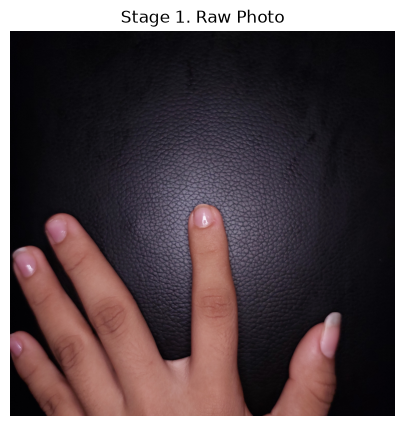

In [3]:
raw_rgb = cv2.cvtColor(cv2.imread(sample_row["raw_path"]), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(raw_rgb)
plt.title("Stage 1. Raw Photo")
plt.axis("off")
plt.show()

## Stage 2. Finger and Nail Plate Segmentation

Jari disegmentasi lewat thresholding warna kulit YCbCr, lalu area fingertip/nail diambil secara geometris dari pita atas mask jari (lihat src/sites/nail/roi.py untuk rincian pendekatan).

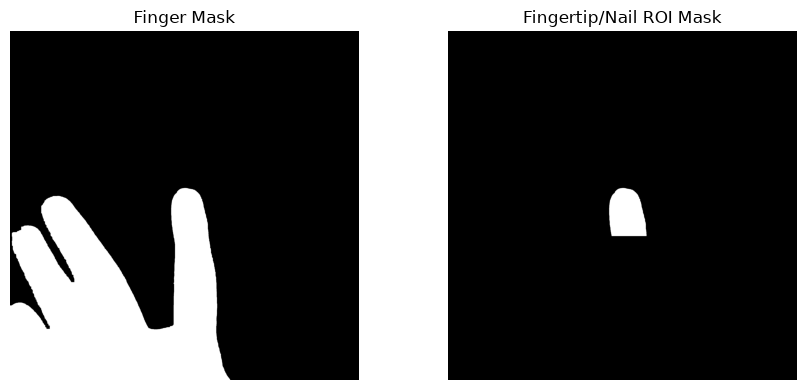

In [4]:
finger_mask = nail_roi.segment_finger(raw_rgb)
nail_mask_full = nail_roi.detect_nail_plate(finger_mask)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(finger_mask, cmap="gray")
axes[0].set_title("Finger Mask")
axes[1].imshow(nail_mask_full, cmap="gray")
axes[1].set_title("Fingertip/Nail ROI Mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Stage 3. Cropped and Normalized ROI

ROI dipotong ke bounding box nail plate, lalu CLAHE pada channel V menstabilkan kontras lokal sebelum ekstraksi fitur.

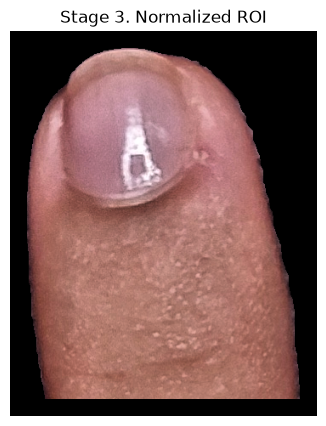

In [5]:
nail_crop = nail_roi.crop_to_mask(raw_rgb, nail_mask_full)
normalized_rgb = preprocess.clahe_on_v(nail_crop["rgb"]).copy()
normalized_rgb[~nail_crop["mask"]] = 0
valid_mask = preprocess.valid_pixel_mask(normalized_rgb, nail_crop["mask"])

plt.figure(figsize=(5, 5))
plt.imshow(normalized_rgb)
plt.title("Stage 3. Normalized ROI")
plt.axis("off")
plt.show()

## Stage 4. Color Biomarker Heatmap

Peta erythema index piksel demi piksel memvisualisasikan bagaimana model membaca sinyal pallor pada permukaan nail bed.

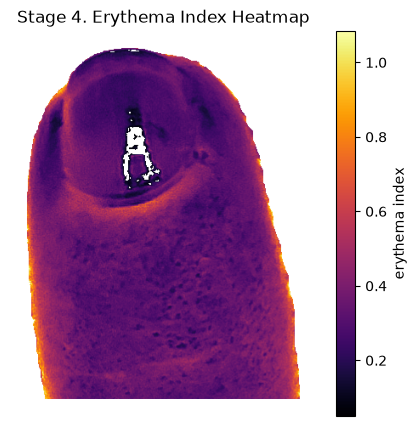

In [6]:
rgb_float = normalized_rgb.astype(np.float32)
mean_g = rgb_float[:, :, 1]
erythema_map = np.log10(1.0 / (mean_g / 255.0 + 1e-6))
erythema_map[~valid_mask] = np.nan

plt.figure(figsize=(5, 5))
plt.imshow(erythema_map, cmap="inferno")
plt.title("Stage 4. Erythema Index Heatmap")
plt.axis("off")
plt.colorbar(label="erythema index")
plt.show()

## Stage 5. Final Prediction Card

Ringkasan hemoglobin dan severity sebenarnya beserta beberapa fitur hand-crafted terpilih, sebagai contoh keluaran akhir aplikasi.

In [7]:
handcrafted_row = features.compute_handcrafted_features(normalized_rgb, valid_mask)
print("uid", sample_row["uid"])
print("hemoglobin sebenarnya", sample_row["hb_gdl"], "g/dL")
print("severity sebenarnya", sample_row["severity"])
print("red_ratio", round(handcrafted_row["red_ratio"], 4))
print("erythema_index", round(handcrafted_row["erythema_index"], 4))

uid nail_ID387
hemoglobin sebenarnya 11.6 g/dL
severity sebenarnya Mild
red_ratio 0.4328
erythema_index 0.3448


## Analysis Charts (Standalone Export)

Grafik perbandingan model dan Bland-Altman final untuk dilampirkan langsung ke proposal tanpa perlu menjalankan ulang notebook training. Model produksi terpilih adalah path_b_deep (lihat Stage 5 dan Stage 6).

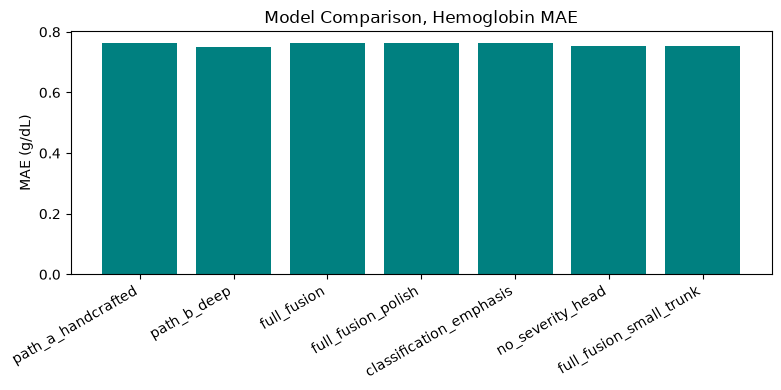

In [8]:
comparison_table = pd.read_csv(output_dir / "multitask_model_comparison.csv")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison_table["configuration"], comparison_table["mae"], color="teal")
ax.set_ylabel("MAE (g/dL)")
ax.set_title("Model Comparison, Hemoglobin MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

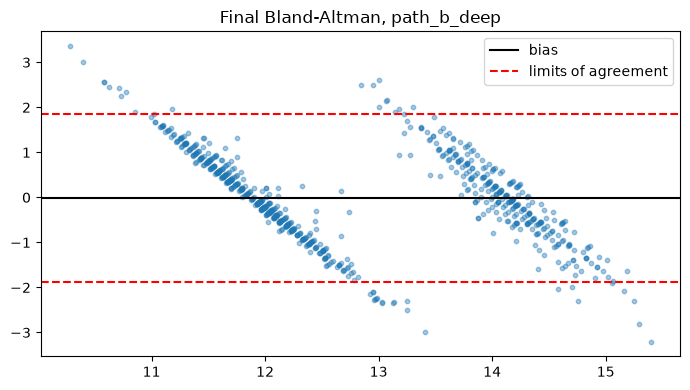

In [9]:
oof_final = pd.read_csv(output_dir / "multitask_oof_best_f1.csv")
bland_altman = evaluation.bland_altman_stats(oof_final["hb_true"], oof_final["hb_pred"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(bland_altman["mean_value"], bland_altman["difference"], alpha=0.4, s=10)
ax.axhline(bland_altman["bias"], color="black", label="bias")
ax.axhline(bland_altman["lower_limit"], color="red", linestyle="--", label="limits of agreement")
ax.axhline(bland_altman["upper_limit"], color="red", linestyle="--")
ax.set_title("Final Bland-Altman, path_b_deep")
ax.legend()
plt.tight_layout()
plt.show()